<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/object_detection_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, glob, random
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

SEED = 0
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = 224
S        = 7
B        = 2
K        = 2      # classes: 0 = cat, 1 = dog
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 0.5

BATCH   = 32
EPOCHS  = 60
SUBSET  = None
CLASS_NAMES = ["cat", "dog"]

In [2]:
# Head bounding boxes live in `annotations/xmls/` and cover ~3,686 images.

# Download data
BASE = "https://www.robots.ox.ac.uk/~vgg/data/pets/data"
if not os.path.exists("images"):
    os.system(f"wget -q {BASE}/images.tar.gz && tar -xzf images.tar.gz")
if not os.path.exists("annotations"):
    os.system(f"wget -q {BASE}/annotations.tar.gz && tar -xzf annotations.tar.gz")
print("images/ exists:", os.path.exists("images"),
      "| xmls:", len(glob.glob("annotations/xmls/*.xml")))

# Parse annotations

# (img_path, cx, cy, w, h, label), box coords in [0,1]
def parse_voc_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    W = float(size.find("width").text); H = float(size.find("height").text)
    bb = root.find("object").find("bndbox")
    xmin = float(bb.find("xmin").text); ymin = float(bb.find("ymin").text)
    xmax = float(bb.find("xmax").text); ymax = float(bb.find("ymax").text)
    return W, H, xmin, ymin, xmax, ymax

records = []
for xml_path in sorted(glob.glob("annotations/xmls/*.xml")):
    name = os.path.splitext(os.path.basename(xml_path))[0]
    img_path = os.path.join("images", name + ".jpg")
    if not os.path.exists(img_path):
        continue
    try:
        W, H, xmin, ymin, xmax, ymax = parse_voc_xml(xml_path)
    except Exception:
        continue
    if W <= 0 or H <= 0 or xmax <= xmin or ymax <= ymin:
        continue
    label = 0 if name[0].isupper() else 1          # 0 = cat, 1 = dog
    cx = ((xmin + xmax) / 2) / W; cy = ((ymin + ymax) / 2) / H
    w  = (xmax - xmin) / W;       h  = (ymax - ymin) / H
    records.append((img_path, cx, cy, w, h, label))

random.shuffle(records)
if SUBSET:
    records = records[:SUBSET]
n_test = max(1, int(0.15 * len(records)))
test_records, train_records = records[:n_test], records[n_test:]
print(f"total={len(records)}  train={len(train_records)}  test={len(test_records)}")

images/ exists: True | xmls: 3686
total=3686  train=3134  test=552


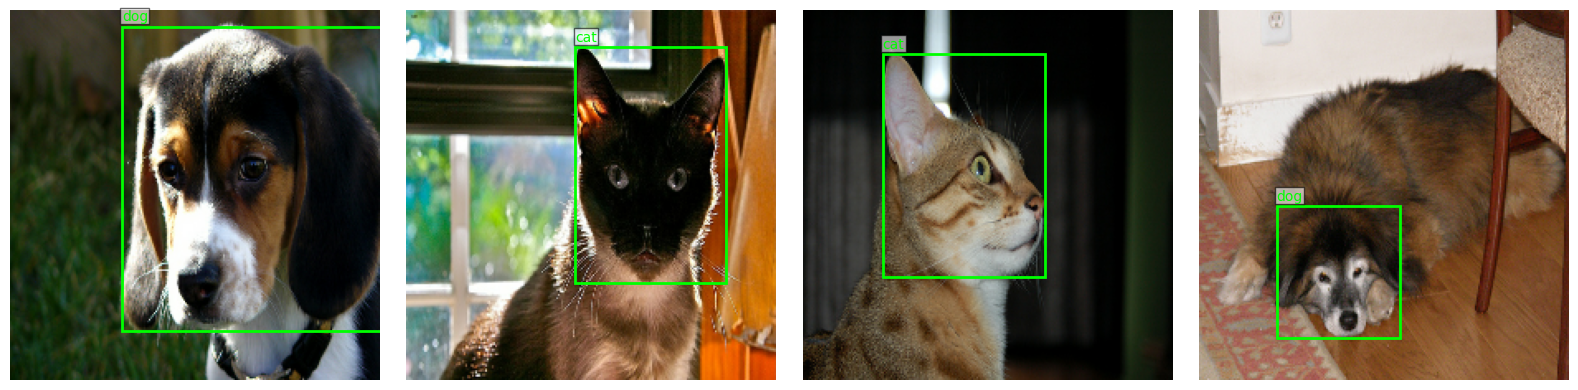

In [3]:
# Target encoding + tf.data pipeline
# Each image yields an (S, S, 5+K) target with channels [x, y, w, h, obj, c0, c1]
# placed in the cell that contains the object centre; all other cells are 0.


def encode_target(cx, cy, w, h, cls_onehot):
    j = tf.clip_by_value(tf.cast(tf.floor(cx * S), tf.int32), 0, S - 1)  # column -> x
    i = tf.clip_by_value(tf.cast(tf.floor(cy * S), tf.int32), 0, S - 1)  # row    -> y
    x_cell = cx * S - tf.cast(j, tf.float32)
    y_cell = cy * S - tf.cast(i, tf.float32)
    vec = tf.concat([[x_cell, y_cell, w, h, 1.0], cls_onehot], axis=0)   # (5+K,)
    return tf.scatter_nd([[i, j]], [vec], shape=(S, S, 5 + K))

def load_and_encode(path, box, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)       # -> [-1, 1]
    target = encode_target(box[0], box[1], box[2], box[3], tf.one_hot(label, K))
    return img, target

def make_dataset(recs, training):
    paths  = [r[0] for r in recs]
    boxes  = np.array([[r[1], r[2], r[3], r[4]] for r in recs], np.float32)
    labels = np.array([r[5] for r in recs], np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, boxes, labels))
    ds = ds.map(load_and_encode, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_records, training=True)
test_ds  = make_dataset(test_records,  training=False)


# Visualise ground-truth boxes (sanity check)


def deprocess(img):
    return np.clip((img + 1.0) / 2.0, 0, 1)

def draw_box(ax, box_xywh, color, label=None):
    cx, cy, w, h = box_xywh
    x1, y1 = (cx - w / 2) * IMG_SIZE, (cy - h / 2) * IMG_SIZE
    ax.add_patch(patches.Rectangle((x1, y1), w * IMG_SIZE, h * IMG_SIZE,
                                   fill=False, edgecolor=color, linewidth=2))
    if label:
        ax.text(x1, y1 - 4, label, color=color, fontsize=10,
                bbox=dict(facecolor="white", alpha=0.6, pad=1))

def show_examples(recs, n=4):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for ax, r in zip(axes, recs[:n]):
        path, cx, cy, w, h, label = r
        img = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), 3),
                              (IMG_SIZE, IMG_SIZE)).numpy() / 255.0
        ax.imshow(img); ax.axis("off")
        draw_box(ax, (cx, cy, w, h), "lime", CLASS_NAMES[label])
    plt.tight_layout(); plt.show()

show_examples(train_records)

In [25]:
#calculating IOU
s=7
#boxes1=[x, y, w, h]
boxes1=[0.5, 0.5, 0.2, 0.1]
boxes2=[0.5, 0.5, 0.4, 0.5]

#cell=(c0,c1)
cell=(3,2)

boxes={}

box_lists=[boxes1, boxes2]
print(box_lists)
print(box_lists[0][2])

for i in range(len(box_lists)):

  #center of the box relative to the image
  cx= (cell[0] + box_lists[i][0]) / s
  cy= (cell[1] + box_lists[i][1]) / s

  w=box_lists[i][2]
  h=box_lists[i][3]

  #top-left corner of the box
  x1=cx - (w/2)
  y1=cy - (h/2)

  #bottom-right corner of the box
  x2=cx + (w/2)
  y2=cy + (h/2)

  boxes.setdefault(i,[x1,y1,x2,y2])

print(boxes.values())
print(boxes[0][0])

overlap_left=tf.maximum(boxes[0][0] , boxes[1][0])
overlap_top=tf.maximum(boxes[0][1] , boxes[1][1])

overlap_right=tf.minimum(boxes[0][2] , boxes[1][2])
overlap_bottom=tf.minimum(boxes[0][3] , boxes[1][3])

intersection_width=overlap_right - overlap_left
intersection_height=overlap_bottom - overlap_top

intersection=intersection_width * intersection_height

area_box1 = (boxes[0][2] - boxes[0][0]) * (boxes[0][3] - boxes[0][1])
area_box2 = (boxes[1][2] - boxes[1][0]) * (boxes[1][3] - boxes[1][1])

union= area_box1 + area_box2 - intersection

IOU= intersection / union

print(IOU)

[[0.5, 0.5, 0.2, 0.1], [0.5, 0.5, 0.4, 0.5]]
0.2
dict_values([[0.4, 0.30714285714285716, 0.6, 0.40714285714285714], [0.3, 0.10714285714285715, 0.7, 0.6071428571428572]])
0.4
tf.Tensor(0.10000001, shape=(), dtype=float32)


In [ ]:
#  TODO  IoU between two (..., S, S, 4) tensors of boxes
def iou(boxes1, boxes2):
    """Each box is [x, y, w, h] with x,y relative to its grid cell and w,h
    relative to the image. Convert both to ABSOLUTE corner boxes (x1,y1,x2,y2)
    in [0,1] — remember to add the cell's (column, row) offset to x,y and divide
    by S — then return the IoU with shape (..., S, S) = intersection / union."""

    raise NotImplementedError

# Output activation + bias init
def yolo_activation(raw):
    parts = []
    for b in range(B):                                   # per box: sigmoid x,y,w,h,C
        s = raw[..., b * 5:(b + 1) * 5]
        parts.append(tf.concat([tf.sigmoid(s[..., 0:4]), tf.sigmoid(s[..., 4:5])], -1))
    parts.append(tf.nn.softmax(raw[..., B * 5:B * 5 + K], -1))   # class probabilities
    return tf.concat(parts, -1)

def head_bias_init(shape, dtype=None):
    b = np.zeros(shape, np.float32)
    for box in range(B):
        b[box * 5 + 4] = -4.0                            # conf logits -> sigmoid ~ 0.018
    return tf.convert_to_tensor(b, dtype=dtype or tf.float32)

# TODO: YOLO model
def build_yolo_model(freeze=True):
    """Frozen ImageNet-pretrained MobileNetV2 (input 224x224 -> 7x7 feature map)
    followed by a small head:
        2x [ Conv2D(256, 3, padding='same', use_bias=False) -> BatchNormalization
             -> LeakyReLU(0.1) ]
        Conv2D(B*5 + K, 1, padding='same', bias_initializer=head_bias_init)
        -> wrap the result with yolo_activation
    Return a tf.keras.Model. (LeakyReLU avoids dead units; the negative confidence
    bias prevents the collapse described above.)"""
    raise NotImplementedError

# TODO: YOLO loss from lecture
def yolo_loss(y_true, y_pred):
    """y_true: (b, S, S, 5+K) = [x, y, w, h, obj, c0, c1]
       y_pred: (b, S, S, B*5+K) = [b1(x,y,w,h,C), b2(x,y,w,h,C), c0, c1]
    Return the total loss divided by the batch size."""
    raise NotImplementedError


In [ ]:
# Train
model = build_yolo_model(freeze=True)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4, clipnorm=1.0), loss=yolo_loss)
model.summary()
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

#Inference and evaluation

# TODO: Decode predictions (threshold + convert to corners + NMS)
def decode(pred, conf_thresh=0.2):
    """pred: (S, S, B*5+K) numpy. For every cell and every box, drop boxes with
    confidence < conf_thresh, convert (cell-relative x,y / image-relative w,h) to
    absolute corner boxes, label each box with the most probable class of its cell,
    and remove duplicates with tf.image.non_max_suppression. Return kept
    (boxes_xyxy, scores, classes)."""
    raise NotImplementedError

# Corner-box IoU
def iou_xyxy(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / (ua + 1e-9)

# TODO: Evaluate: mean IoU, accuracy@0.5, class accuracy
def evaluate(model, recs):
    """For each image: run the model, decode (use conf_thresh=0.0 so a box is
    always returned), take the highest-confidence predicted box, and compare it to
    the single ground-truth box via iou_xyxy. Print the mean IoU, the fraction of
    images with IoU >= 0.5, and the class accuracy."""
    raise NotImplementedError

evaluate(model, test_records)

# Visualise predictions (provided — green = ground truth, red = prediction)
def show_predictions(model, recs, n=4, conf_thresh=0.2):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for ax, r in zip(axes, recs[:n]):
        path, cx, cy, w, h, label = r
        raw = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), 3),
                              (IMG_SIZE, IMG_SIZE))
        pred = model(tf.keras.applications.mobilenet_v2.preprocess_input(raw)[None]).numpy()[0]
        ax.imshow(raw.numpy() / 255.0); ax.axis("off")
        draw_box(ax, (cx, cy, w, h), "lime", "GT:" + CLASS_NAMES[label])
        boxes, scores, classes = decode(pred, conf_thresh)
        for box, sc, cl in zip(boxes, scores, classes):
            bx = ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2,
                  box[2] - box[0], box[3] - box[1])
            draw_box(ax, bx, "red", f"{CLASS_NAMES[cl]} {sc:.2f}")
    plt.tight_layout(); plt.show()

show_predictions(model, test_records)

NotImplementedError: 